見つかったファイル: ['results_pz_0.0_Lx_20_Nd_500_NT_12000.npz']
results_pz_0.0_Lx_20_Nd_500_NT_12000.npz: Lx= 6


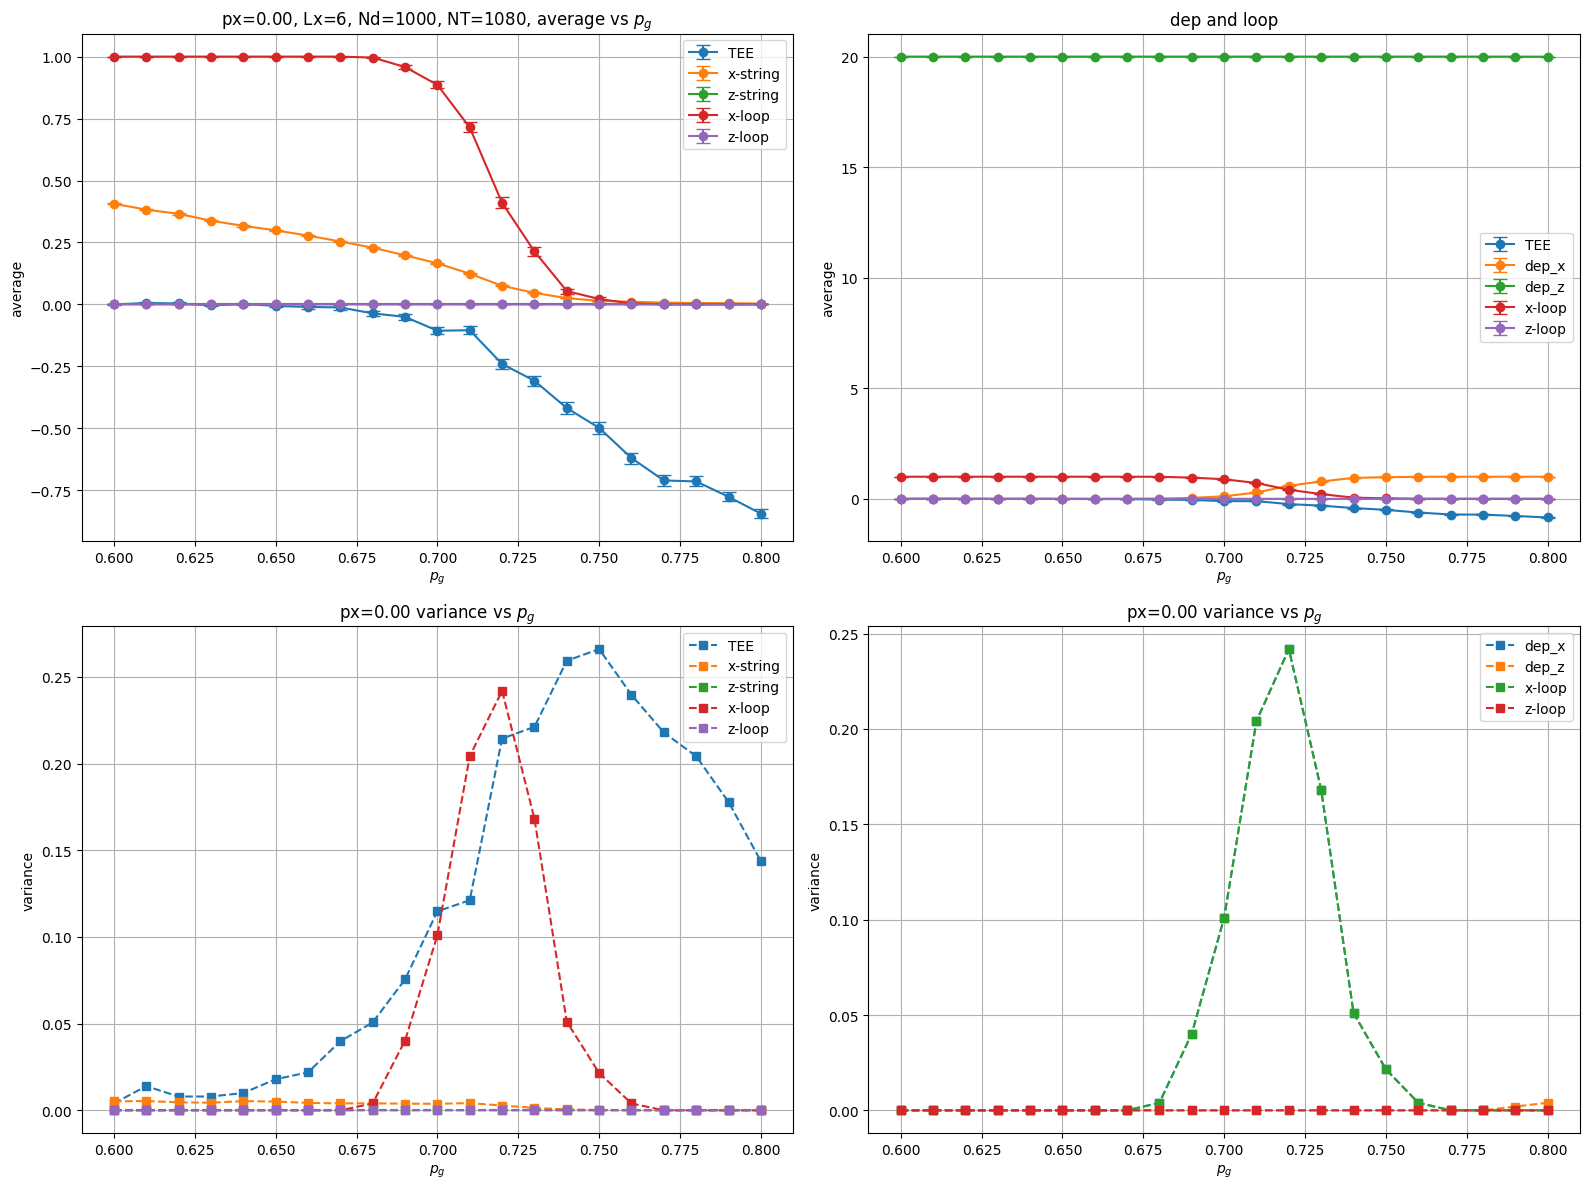

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# カラーマップ設定
cmap = plt.colormaps['gnuplot']

# ファイル読み込み
files = glob.glob("results_pz_0.0_Lx_20_Nd_500_NT_12000.npz")
print("見つかったファイル:", files)

for file in files:
    match = re.search(
        r"px_([0-9.]+)_Lx_(\d+)_Nd_(\d+)_NT_(\d+)", file
    )
    if match:
        px = float(match.group(1))
        Lx = int(match.group(2))
        Nd = int(match.group(3))
        NT = int(match.group(4))
        print(f"{file} → Lx={Lx}, Nd={Nd}, NT={NT}, px={px}")

# プロット用
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

for file in files:
    with np.load(file) as data:
        pg = data['pg']                      # ← 必ず最初に読み込む
        sort_idx = np.argsort(pg)           # ← 昇順インデックス
        pg = pg[sort_idx]                   # ← 並び替え
                
        TEE_ave = data['TEE_ave'][sort_idx]
        TEE_err = data['TEE_err'][sort_idx]
        TEE_var = data['TEE_var'][sort_idx]
        R2x_ave = data['R2x_ave'][sort_idx]
        R2x_err = data['R2x_err'][sort_idx]
        R2x_var = data['R2x_var'][sort_idx]
        R2z_ave = data['R2z_ave'][sort_idx]
        R2z_err = data['R2z_err'][sort_idx]
        R2z_var = data['R2z_var'][sort_idx]
        R2x_loop_ave = data['R2x_loop_ave'][sort_idx]
        R2x_loop_err = data['R2x_loop_err'][sort_idx]
        R2x_loop_var = data['R2x_loop_var'][sort_idx]
        R2z_loop_ave = data['R2z_loop_ave'][sort_idx]
        R2z_loop_err = data['R2z_loop_err'][sort_idx]
        R2z_loop_var = data['R2z_loop_var'][sort_idx]
        dep_x_ave = data['dep_x_ave'][sort_idx]
        dep_x_err = data['dep_x_err'][sort_idx]
        dep_x_var = data['dep_x_var'][sort_idx]
        dep_z_ave = data['dep_z_ave'][sort_idx]
        dep_z_err = data['dep_z_err'][sort_idx]
        dep_z_var = data['dep_z_var'][sort_idx]

    #label = f"px={px:.2f}"
    label =f"ee"
    # 左グラフ：TEEと相関の平均＋誤差
    ax[0,0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,0].errorbar(pg, R2x_ave, yerr=R2x_err, fmt='o-', capsize=5, label="x-string")
    ax[0,0].errorbar(pg, R2z_ave, yerr=R2z_err, fmt='o-', capsize=5, label="z-string")
    ax[0,0].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,0].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    # 右グラフ：分散
    ax[0,1].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,1].errorbar(pg, dep_x_ave, yerr=dep_x_err, fmt='o-', capsize=5, label="dep_x")
    ax[0,1].errorbar(pg, dep_z_ave, yerr=dep_z_err, fmt='o-', capsize=5, label="dep_z")
    ax[0,1].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,1].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    ax[1,0].plot(pg, TEE_var, 's--', label="TEE")    
    ax[1,0].plot(pg, R2x_var, 's--', label="x-string")
    ax[1,0].plot(pg, R2z_var, 's--', label="z-string")
    ax[1,0].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,0].plot(pg, R2z_loop_var, 's--', label="z-loop")
    
    ax[1,1].plot(pg, dep_x_var, 's--', label="dep_x")
    ax[1,1].plot(pg, dep_z_var, 's--', label="dep_z")
    ax[1,1].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,1].plot(pg, R2z_loop_var, 's--', label="z-loop")
    print(f"{file}: Lx= {Lx}")

# 描画設定
ax[0,0].set_xlabel('$p_g$')
ax[0,0].set_ylabel('average')
ax[0,0].set_title(f"px={px:.2f}, Lx={Lx}, Nd={Nd}, NT={NT}, average vs $p_g$")
ax[0,0].grid(True)
ax[0,0].legend()

ax[0,1].set_xlabel('$p_g$')
ax[0,1].set_ylabel('average')
ax[0,1].set_title("dep and loop")
ax[0,1].grid(True)
ax[0,1].legend()

ax[1,0].set_xlabel('$p_g$')
ax[1,0].set_ylabel('variance')
ax[1,0].set_title(f"px={px:.2f} variance vs $p_g$")
ax[1,0].grid(True)
ax[1,0].legend()

ax[1,1].set_xlabel('$p_g$')
ax[1,1].set_ylabel('variance')
ax[1,1].set_title(f"px={px:.2f} variance vs $p_g$")
ax[1,1].grid(True)
ax[1,1].legend()

plt.tight_layout()
#plt.savefig(f"px_{px:.2f}_Lx_{Lx}_Nd_{Nd}_NT_{NT}_results.png", dpi=300, bbox_inches='tight')
plt.show()
